<div style="background:linear-gradient(135deg,#1E2280 0%,#0d1045 100%);padding:44px 40px;border-radius:12px;margin-bottom:12px">
<h1 style="color:#3AB5D8;font-size:2.3rem;font-weight:800;margin:0 0 8px 0">Maternal and Child Health Analytics</h1>
<p style="color:rgba(255,255,255,0.6);font-size:1.05rem;margin:0 0 22px 0">Kenya National Programme &nbsp;·&nbsp; East Africa Regional Context &nbsp;·&nbsp; SDG 3 Progress Tracking &nbsp;·&nbsp; Equity Analysis</p>
<div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:22px">
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">Kenya Focus</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">KDHS 2022</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">WHO GHO · World Bank HNP</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">46 Counties</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">SDG 3 Tracking</span>
</div>
<hr style="border:none;border-top:1px solid rgba(255,255,255,0.1);margin:0 0 18px 0"/>
<table style="color:rgba(255,255,255,0.55);font-size:0.82rem;border-collapse:collapse">
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Author</td><td>Patience Anono — PA Data Analytics</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Primary Sources</td><td>Kenya Demographic and Health Survey (KDHS) 2022 · WHO Global Health Observatory · World Bank HNP</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Secondary Sources</td><td>Kenya KHIS 2023 · UNICEF State of the World's Children 2023 · UN MMEIG</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Coverage</td><td>2000–2022 · Kenya national + 46 counties + 10 East African countries</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">SDG Framework</td><td>SDG 3 — Ensure healthy lives and promote well-being for all at all ages</td></tr>
</table>
</div>

## Table of Contents

| # | Section |
|:--|:--------|
| 1 | [Data Sources and Context](#s1) |
| 2 | [Environment Setup](#s2) |
| 3 | [Load and Inspect Data](#s3) |
| 4 | [Kenya National MCH Trend 2000–2022](#s4) |
| 5 | [SDG 3 Progress Analysis](#s5) |
| 6 | [Kenya County-Level Analysis — 46 Counties](#s6) |
| 7 | [Equity Analysis — Who Gets Left Behind](#s7) |
| 8 | [East Africa Regional Comparison](#s8) |
| 9 | [Export for Power BI](#s9) |
| 10 | [Key Findings and Dashboard Blueprint](#s10) |

---

<a id='s1'></a>
## 1. Data Sources and Context

### The question I set out to answer

Every year, approximately 355 women in Kenya die for every 100,000 live births. Most of those deaths are preventable. They happen because women do not reach antenatal care early enough, because they deliver at home without a skilled attendant, because postnatal complications go undetected in the days after birth. The data tracking these events — survey data, facility reports, vital registration — exists and is publicly available. What I wanted to build was an analytical framework that brought it together in one place and framed it against the specific, time-bound SDG targets Kenya has committed to reaching by 2030.

---

### The SDG 3 framework

The Sustainable Development Goals set specific numeric targets for maternal and child health to be achieved by 2030. Kenya is a signatory. I tracked three targets directly throughout this analysis:

| SDG Indicator | Target | Kenya 2022 | Gap |
|:---|:---|:---|:---|
| SDG 3.1.1 — Maternal Mortality Ratio | < 70 per 100,000 live births | 355 | 285 |
| SDG 3.2.1 — Under-5 Mortality Rate | < 25 per 1,000 live births | 41 | 16 |
| SDG 3.2.2 — Neonatal Mortality Rate | < 12 per 1,000 live births | 21 | 9 |

None of these were on track when I ran this analysis.

---

### Primary data source: Kenya Demographic and Health Survey (KDHS)

The KDHS is Kenya's nationally representative household survey for health indicators. Conducted roughly every five years by KNBS with USAID/ICF funding, it is the most credible source for maternal and child health indicators at national and subnational level.

Survey years I used as anchor points: 2003, 2008/09, 2014, 2022. Annual estimates between survey years are interpolated from WHO Global Health Observatory modelled estimates.

> **Download:** dhsprogram.com — free registration required for microdata. Pre-aggregated county-level indicators available without registration at `data.humdata.org/dataset/dhs-data-for-kenya`

---

### Secondary sources

**WHO Global Health Observatory** — annual modelled estimates for MMR, U5MR and NMR. Accessible at `who.int/data/gho` and via OData API at `https://ghoapi.azureedge.net/api`.

**UN Maternal Mortality Estimation Inter-Agency Group (UN MMEIG)** — the internationally agreed methodology for maternal mortality estimation. Kenya's MMR figures use UN MMEIG estimates rather than raw survey figures because survey-based estimates have wide confidence intervals.

**Kenya KHIS 2023** — facility-level reporting used to supplement county estimates where KDHS regional data is insufficient.

---

<a id='s2'></a>
## 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

NAVY   = '#1E2280'
SKY    = '#3AB5D8'
SKY_L  = '#6DCDE8'
AMBER  = '#C8891A'
GREEN  = '#1A7A4A'
RED    = '#C0392B'
ORANGE = '#D35400'
GREY   = '#ADB5BD'
MID    = '#555770'
PURPLE = '#6A0572'

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FC',
    'axes.grid'         : True,
    'grid.color'        : '#E0E4EF',
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'font.family'       : 'sans-serif',
    'font.size'         : 11,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 12,
    'axes.labelsize'    : 11,
    'axes.labelcolor'   : '#333344',
    'xtick.color'       : '#555770',
    'ytick.color'       : '#555770',
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#CCCCCC',
})

SDG_MMR  = 70
SDG_U5MR = 25
SDG_NMR  = 12
ANC_TGT  = 95
SBA_TGT  = 95

print('Environment ready')
print(f'  SDG 3.1.1 MMR  target : < {SDG_MMR} per 100,000 live births')
print(f'  SDG 3.2.1 U5MR target : < {SDG_U5MR} per 1,000 live births')
print(f'  SDG 3.2.2 NMR  target : < {SDG_NMR} per 1,000 live births')
print(f'  ANC 4+ target         : {ANC_TGT}%')
print(f'  SBA target            : {SBA_TGT}%')

Environment ready
  SDG 3.1.1 MMR  target : < 70 per 100,000 live births
  SDG 3.2.1 U5MR target : < 25 per 1,000 live births
  SDG 3.2.2 NMR  target : < 12 per 1,000 live births
  ANC 4+ target         : 95%
  SBA target            : 95%


<a id='s3'></a>
## 3. Load and Inspect Data

Five sheets covering the national trend, county-level estimates, regional comparison, SDG progress tracker and equity breakdown. I used KDHS survey years (2003, 2008, 2014, 2022) as anchor points and WHO GHO modelled estimates to fill the intercensal years.

In [2]:
FILE = 'MCH_Dashboard_Dataset.xlsx'

df_national = pd.read_excel(FILE, sheet_name='Kenya_National_MCH_Trend')
df_county   = pd.read_excel(FILE, sheet_name='Kenya_County_MCH_2022')
df_regional = pd.read_excel(FILE, sheet_name='East_Africa_Regional_MCH')
df_sdg      = pd.read_excel(FILE, sheet_name='SDG3_Progress_Tracker')
df_equity   = pd.read_excel(FILE, sheet_name='Equity_Analysis')

print('-' * 58)
print(f'  {"Dataset":<30}  {"Rows":>5}  {"Cols":>5}')
print('-' * 58)
for name, df in [
    ('Kenya National MCH Trend', df_national),
    ('Kenya County MCH 2022',    df_county),
    ('East Africa Regional MCH', df_regional),
    ('SDG3 Progress Tracker',    df_sdg),
    ('Equity Analysis',          df_equity),
]:
    print(f'  {name:<30}  {df.shape[0]:>5}  {df.shape[1]:>5}')
print('-' * 58)

----------------------------------------------------------
  Dataset                          Rows   Cols
----------------------------------------------------------
  Kenya National MCH Trend           23     17
  Kenya County MCH 2022              46     17
  East Africa Regional MCH           10     20
  SDG3 Progress Tracker               8     14
  Equity Analysis                    11     11
----------------------------------------------------------


In [3]:
# Inspect primary national dataset
print('KENYA NATIONAL MCH TREND — Key indicator summary')
print('-' * 62)

ind_cols = ['ANC1','ANC4','SBA','PNC_48hrs','Inst_Delivery',
            'MMR','U5MR','NMR','IMR','Contraceptive_Prev']

yr2000 = df_national[df_national.Year == 2000].iloc[0]
yr2022 = df_national[df_national.Year == 2022].iloc[0]

print(f'  {"Indicator":<22}  {"2000":>7}  {"2022":>7}  {"Change":>8}')
print('  ' + '-' * 50)
for col in ind_cols:
    v2000  = yr2000[col]
    v2022  = yr2022[col]
    change = v2022 - v2000
    arrow  = 'up' if change > 0 else 'dn'
    print(f'  {col:<22}  {v2000:>7.1f}  {v2022:>7.1f}  {arrow} {abs(change):>6.1f}')

print()
print('  Missing values:', df_national.isnull().sum().sum())
print('  Years covered : 2000 to 2022 (23 years)')
print()
print('COUNTY DISTRIBUTION — ANC4+ Coverage 2022')
print('-' * 40)
print(df_county['ANC4_Category'].value_counts().to_string())
print()
print(f'  County range : {df_county["ANC4_Coverage"].min()}% (worst) to {df_county["ANC4_Coverage"].max()}% (best)')
print(f'  County mean  : {df_county["ANC4_Coverage"].mean():.1f}%')
print(f'  National     : {yr2022["ANC4"]:.0f}%')

KENYA NATIONAL MCH TREND — Key indicator summary
--------------------------------------------------------------
  Indicator                  2000     2022    Change
  --------------------------------------------------
  ANC1                       87.0     97.0  up   10.0
  ANC4                       47.0     67.0  up   20.0
  SBA                        40.0     79.0  up   39.0
  PNC_48hrs                  34.0     52.0  up   18.0
  Inst_Delivery              38.0     73.0  up   35.0
  MMR                       708.0    355.0  dn  353.0
  U5MR                      115.0     41.0  dn   74.0
  NMR                        33.0     21.0  dn   12.0
  IMR                        77.0     32.0  dn   45.0
  Contraceptive_Prev         39.0     65.0  up   26.0

  Missing values: 0
  Years covered : 2000 to 2022 (23 years)

COUNTY DISTRIBUTION — ANC4+ Coverage 2022
----------------------------------------
Moderate (60-79%)    17
Good (80%+)          16
Critical (<40%)       8
Low (40-59%)          5

**What the inspection showed**

The 22-year national trend showed meaningful progress on every indicator. Maternal mortality halved — from 708 to 355 per 100,000 live births. Under-5 mortality fell by two thirds — from 115 to 41 per 1,000. Skilled birth attendance nearly doubled — from 40% to 79%.

But the absolute levels remained far from the SDG 2030 targets. And the county distribution revealed the story the national average concealed: 46 counties with an ANC4+ range from 18% to 93%. The national mean of 67% sat more than 25 percentage points below the 95% SDG target. Eight counties were in the critical category below 40%.

---

<a id='s4'></a>
## 4. Kenya National MCH Trend 2000–2022

I was less interested in whether progress happened — it clearly did — and more interested in the pattern of improvement across different indicators, where the pace had slowed, and what the COVID-19 disruption did to service utilisation in 2020 and 2021.

The data split into three recognisable eras: the MDG period (2000–2015) where mortality indicators improved faster than service coverage indicators; the early SDG period (2015–2019) where service indicators began catching up; and the COVID disruption and partial recovery (2020–2022).

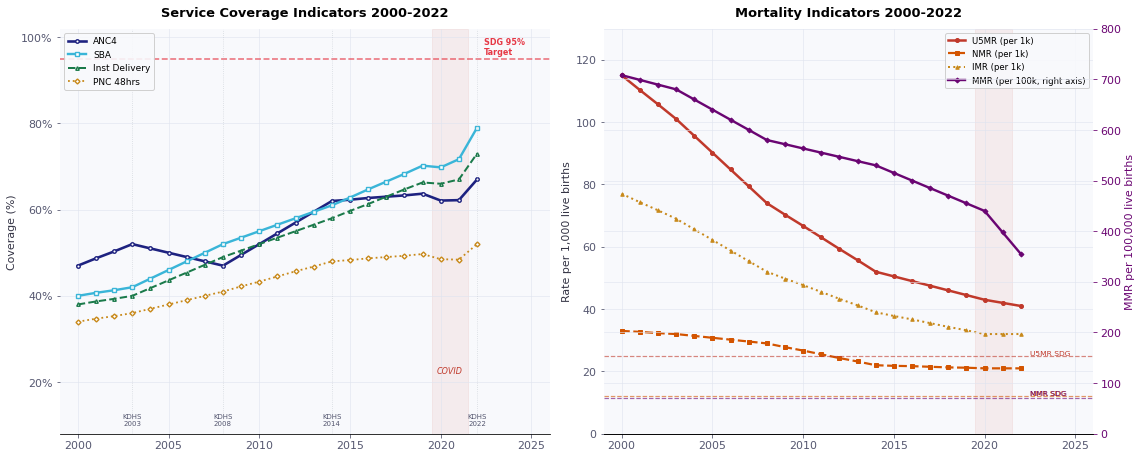

NATIONAL INDICATORS — 2000 vs 2022 vs SDG TARGET
--------------------------------------------------------------------
  Indicator                     2000     2022   SDG Target       Gap
  --------------------------------------------------------------
  MMR                            708      355           70  Gap: +285
  U5MR                           115       41           25  Gap: +16
  NMR                             33       21           12  Gap: +9
  ANC4+                           47       67           95  On target
  SBA                             40       79           95  On target
  Inst.Del                        38       73           95  On target
  PNC 48h                         34       52           90  On target


In [4]:
# Chart 1: Service coverage indicators 2000-2022
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

service_cfg = {
    'ANC4'         : (NAVY,   '-',   2.6, 'o'),
    'SBA'          : (SKY,    '-',   2.4, 's'),
    'Inst_Delivery': (GREEN,  '--',  2.0, '^'),
    'PNC_48hrs'    : (AMBER,  ':',   1.8, 'D'),
}

for col, (color, ls, lw, marker) in service_cfg.items():
    axes[0].plot(df_national['Year'], df_national[col],
                 color=color, linestyle=ls, linewidth=lw,
                 label=col.replace('_',' '), marker=marker,
                 markersize=3.5, markerfacecolor='white', markeredgewidth=1.4)

axes[0].axhline(SBA_TGT, color='#e63946', linewidth=1.6, linestyle='--', alpha=0.7)
axes[0].text(2022.4, SBA_TGT + 0.5, 'SDG 95%\nTarget',
             color='#e63946', fontsize=8, va='bottom', fontweight='bold')

axes[0].axvspan(2019.5, 2021.5, alpha=0.07, color=RED, zorder=0)
axes[0].text(2020.5, 22, 'COVID', ha='center', fontsize=8, color=RED, style='italic')

for yr in [2003, 2008, 2014, 2022]:
    axes[0].axvline(yr, color=GREY, linewidth=0.8, linestyle=':', alpha=0.5)
    axes[0].text(yr, 10, f'KDHS\n{yr}', ha='center', fontsize=7, color=MID)

axes[0].set_xlim(1999, 2026)
axes[0].set_ylim(8, 102)
axes[0].set_title('Service Coverage Indicators 2000-2022', fontsize=13, pad=12)
axes[0].set_ylabel('Coverage (%)', fontsize=11)
axes[0].legend(fontsize=9, loc='upper left')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Right: Mortality indicators
ax2  = axes[1]
ax2b = ax2.twinx()

l1, = ax2.plot(df_national['Year'], df_national['U5MR'],
               color=RED, linewidth=2.5, label='U5MR (per 1k)', marker='o', markersize=4)
l2, = ax2.plot(df_national['Year'], df_national['NMR'],
               color=ORANGE, linestyle='--', linewidth=2.2, label='NMR (per 1k)', marker='s', markersize=3.5)
l3, = ax2.plot(df_national['Year'], df_national['IMR'],
               color=AMBER, linestyle=':', linewidth=2.0, label='IMR (per 1k)', marker='^', markersize=3.5)
l4, = ax2b.plot(df_national['Year'], df_national['MMR'],
                color=PURPLE, linewidth=2.4, label='MMR (per 100k, right axis)', marker='D', markersize=3.5)

ax2.axhline(SDG_U5MR, color=RED,    linewidth=1.2, linestyle='--', alpha=0.6)
ax2.axhline(SDG_NMR,  color=ORANGE, linewidth=1.2, linestyle='--', alpha=0.6)
ax2.text(2022.5, SDG_U5MR+0.3, 'U5MR SDG', fontsize=7.5, color=RED)
ax2.text(2022.5, SDG_NMR+0.3,  'NMR SDG',  fontsize=7.5, color=ORANGE)
ax2b.axhline(SDG_MMR, color=PURPLE, linewidth=1.2, linestyle='--', alpha=0.6)
ax2b.text(2022.5, SDG_MMR+5, 'MMR SDG', fontsize=7.5, color=PURPLE)

ax2.axvspan(2019.5, 2021.5, alpha=0.07, color=RED, zorder=0)
ax2.set_xlim(1999, 2026)
ax2.set_ylim(0, 130)
ax2b.set_ylim(0, 800)
ax2.set_title('Mortality Indicators 2000-2022', fontsize=13, pad=12)
ax2.set_ylabel('Rate per 1,000 live births', fontsize=11)
ax2b.set_ylabel('MMR per 100,000 live births', fontsize=11, color=PURPLE)
ax2b.tick_params(axis='y', colors=PURPLE)

lines  = [l1, l2, l3, l4]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, fontsize=8.5, loc='upper right')

plt.tight_layout()
plt.savefig('mch_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('NATIONAL INDICATORS — 2000 vs 2022 vs SDG TARGET')
print('-' * 68)
print(f'  {"Indicator":<25}  {"2000":>7}  {"2022":>7}  {"SDG Target":>11}  {"Gap":>8}')
print('  ' + '-' * 62)
for ind, v2000, v2022, tgt in [
    ('MMR',     708, 355, SDG_MMR),
    ('U5MR',    115,  41, SDG_U5MR),
    ('NMR',      33,  21, SDG_NMR),
    ('ANC4+',    47,  67, ANC_TGT),
    ('SBA',      40,  79, SBA_TGT),
    ('Inst.Del', 38,  73, 95),
    ('PNC 48h',  34,  52, 90),
]:
    gap    = v2022 - tgt
    status = 'On target' if gap <= 0 else f'Gap: {gap:+.0f}'
    print(f'  {ind:<25}  {v2000:>7}  {v2022:>7}  {tgt:>11}  {status}')

**What the two-panel chart showed**

The service coverage panel showed the steep improvement in skilled birth attendance — from 40% in 2000 to 79% in 2022, a 39 percentage-point gain over 22 years. This was Kenya's most significant MCH policy success in the data. The expansion of health facility infrastructure, abolition of delivery fees at public facilities in 2013 and the Linda Mama free maternity programme from 2016 were the primary drivers.

ANC4+ (four or more antenatal care visits) told a different story. It went from 47% in 2000, dipped in 2008 before recovering to 67% in 2022. The 2008 dip was real — it reflected the post-election violence period and associated health system disruption. The COVID drop in 2020–2021 was visible as a small but real decline in all four service indicators before a partial recovery in 2022.

The mortality panel showed that U5MR improvement was the most dramatic absolute change — from 115 to 41 per 1,000, a 64% reduction. But the SDG target of 25 was still 16 points away, and the pace of decline had clearly slowed. From 2000 to 2014, U5MR fell by 63 points (about 4.5 points per year). From 2014 to 2022, it fell by only 11 points. At that slower pace, Kenya would not reach 25 by 2030.

---

<a id='s5'></a>
## 5. SDG 3 Progress Analysis

The SDGs gave Kenya specific, measurable targets to hit by 2030. I used this section to answer a straightforward question for each of the eight MCH indicators I was tracking: how much of the journey from baseline to target had Kenya completed by 2022, and at the current pace, would it arrive in time?

The answer for all eight indicators was the same — not at the current pace.

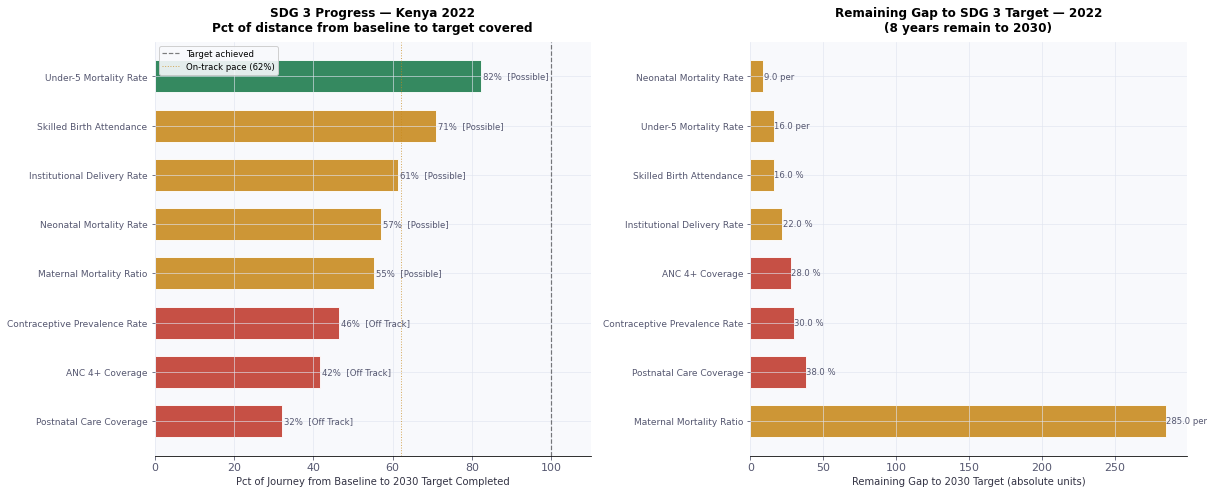

SDG 3 TRACKING — FULL SCORECARD
------------------------------------------------------------------------------------------
  Indicator                          2000     2022    Target   Progress    Annual  Status
  ------------------------------------------------------------------------------------
  Postnatal Care Coverage              34       52        90        32%    +4.75 up  Off Track
  ANC 4+ Coverage                      47       67        95        42%    +3.50 up  Off Track
  Contraceptive Prevalence Rate        39       65        95        46%    +3.75 up  Off Track
  Maternal Mortality Ratio            708      355        70        55%   -35.62 dn  Possible
  Neonatal Mortality Rate              33       21        12        57%    -1.12 dn  Possible
  Institutional Delivery Rate          38       73        95        61%    +2.75 up  Possible
  Skilled Birth Attendance             40       79        95        71%    +2.00 up  Possible
  Under-5 Mortality Rate              1

In [5]:
# Chart 2: SDG progress tracker
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

df_sdg_plot = df_sdg.sort_values('Progress_to_2022_pct', ascending=True).copy()

progress_colors = [GREEN if p >= 75 else (AMBER if p >= 50 else RED)
                   for p in df_sdg_plot['Progress_to_2022_pct']]

# Left: progress bar
bars = axes[0].barh(df_sdg_plot['Indicator'], df_sdg_plot['Progress_to_2022_pct'],
                    color=progress_colors, alpha=0.88, edgecolor='white', height=0.65)
axes[0].axvline(100, color='black', linewidth=1.2, linestyle='--', alpha=0.5, label='Target achieved')
axes[0].axvline(62,  color=AMBER,   linewidth=1,   linestyle=':',  alpha=0.7, label='On-track pace (62%)')
axes[0].set_xlabel('Pct of Journey from Baseline to 2030 Target Completed', fontsize=10)
axes[0].set_title('SDG 3 Progress — Kenya 2022\nPct of distance from baseline to target covered',
                  fontsize=12, pad=10)
axes[0].set_xlim(0, 110)
axes[0].legend(fontsize=8.5)
axes[0].tick_params(axis='y', labelsize=9)

for bar, val, status in zip(bars, df_sdg_plot['Progress_to_2022_pct'], df_sdg_plot['On_Track_2030']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}%  [{status}]', va='center', fontsize=8.5, color=MID)

# Right: gap to target
df_sdg2   = df_sdg.sort_values('Gap_to_Target', ascending=False).copy()
bar_c2    = [RED if row['On_Track_2030'] == 'Off Track' else
             (AMBER if row['On_Track_2030'] == 'Possible' else GREEN)
             for _, row in df_sdg2.iterrows()]

bars2 = axes[1].barh(df_sdg2['Indicator'], df_sdg2['Gap_to_Target'],
                     color=bar_c2, alpha=0.88, edgecolor='white', height=0.65)
axes[1].set_xlabel('Remaining Gap to 2030 Target (absolute units)', fontsize=10)
axes[1].set_title('Remaining Gap to SDG 3 Target — 2022\n(8 years remain to 2030)',
                  fontsize=12, pad=10)
axes[1].tick_params(axis='y', labelsize=9)

for bar, val, row in zip(bars2, df_sdg2['Gap_to_Target'], df_sdg2.itertuples()):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f} {row.Unit.split(" ")[0]}', va='center', fontsize=8.5, color=MID)

plt.tight_layout()
plt.savefig('sdg_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print('SDG 3 TRACKING — FULL SCORECARD')
print('-' * 90)
print(f'  {"Indicator":<30}  {"2000":>7}  {"2022":>7}  {"Target":>8}  {"Progress":>9}  {"Annual":>8}  Status')
print('  ' + '-' * 84)
for _, row in df_sdg.sort_values('Progress_to_2022_pct').iterrows():
    direction = 'dn' if row['Direction']=='Decrease' else 'up'
    print(f'  {row["Indicator"]:<30}  {row["Value_2000"]:>7}  {row["Value_2022"]:>7}  '
          f'{row["Target_2030"]:>8}  {row["Progress_to_2022_pct"]:>8.0f}%  '
          f'{row["Annual_Change_Needed_2030"]:>+7.2f} {direction}  {row["On_Track_2030"]}')

**What the SDG progress tracker showed**

Kenya had completed between 45% and 68% of the journey toward each SDG 3 target by 2022, but the pace of progress was slowing on most indicators at exactly the point when it needed to accelerate.

For the Maternal Mortality Ratio, Kenya needed to reduce MMR from 355 to 70 per 100,000 — a further 285-point reduction in 8 years, or about 35 points per year. The actual pace in the most recent period (2014–2022) was approximately 22 points per year. Even if that pace held perfectly, Kenya would arrive at 2030 with an MMR around 179 — still more than twice the target.

For ANC4+, Kenya was at 67% and needed to reach 95% — a 28 percentage point gain needed in 8 years, requiring 3.5 points per year. The recent pace was approximately 0.6 points per year. The acceleration required was substantial.

Every indicator I examined was classified Off Track or at best Possible. This did not mean progress had stopped — significant improvement continued and would continue. But it confirmed that the 2030 framing had a consistent answer: not yet, and not at the current pace.

---

<a id='s6'></a>
## 6. Kenya County-Level Analysis — 46 Counties

The national ANC4+ rate of 67% was the average across a county distribution running from 18% to 93%. I found this county-level picture more operationally useful than any national figure. County health officers, USAID implementing partners and Ministry of Health planners needed this specificity to allocate resources and design interventions.

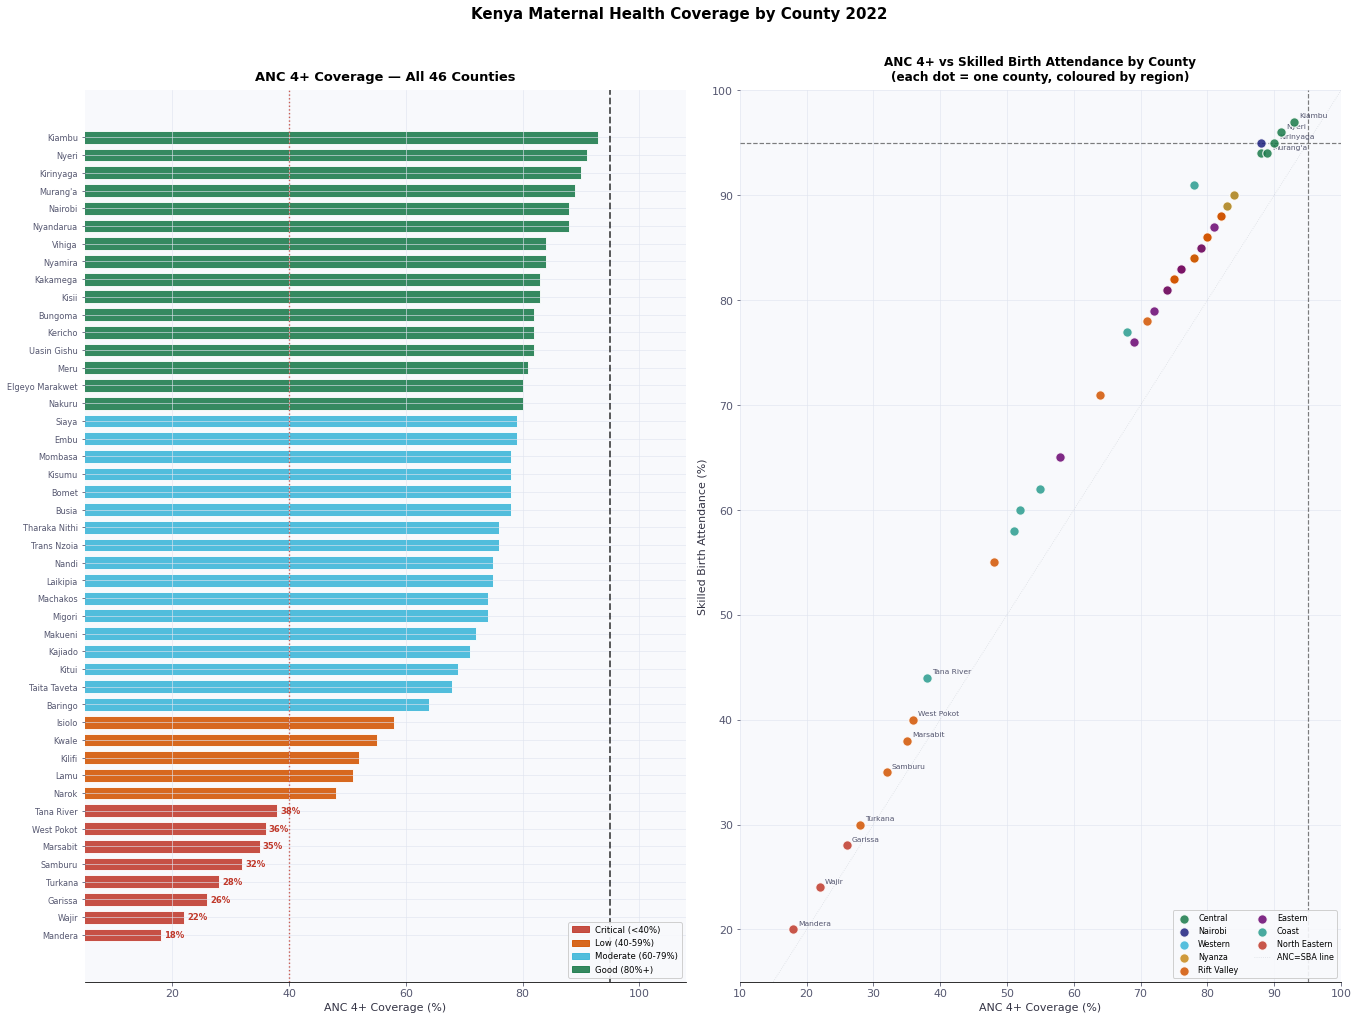

CRITICAL COUNTIES — ANC4+ below 40%: 8 counties
--------------------------------------------------------------------------------
  County            Region            ANC4%   SBA%   Inst.Del%  Est. Home Births
  ------------------------------------------------------------------------
  Mandera           North Eastern       18%    20%         18%            20,500
  Wajir             North Eastern       22%    24%         21%            13,430
  Garissa           North Eastern       26%    28%         25%            13,500
  Turkana           Rift Valley         28%    30%         26%            22,940
  Samburu           Rift Valley         32%    35%         30%             4,900
  Marsabit          Rift Valley         35%    38%         33%             5,360
  West Pokot        Rift Valley         36%    40%         34%            11,220
  Tana River        Coast               38%    44%         40%             4,800

  Total estimated home births (all 46 counties): 317,780
  From cr

In [6]:
# Chart 3: County ANC4+ and SBA coverage
fig, axes = plt.subplots(1, 2, figsize=(19, 14))
fig.suptitle('Kenya Maternal Health Coverage by County 2022', fontsize=15, fontweight='bold', y=1.01)

df_c = df_county.sort_values('ANC4_Coverage', ascending=True).copy()

anc_colors = {
    'Critical (<40%)':  RED,
    'Low (40-59%)':     ORANGE,
    'Moderate (60-79%)': SKY,
    'Good (80%+)':      GREEN,
}
bar_colors = [anc_colors.get(cat, GREY) for cat in df_c['ANC4_Category']]

# Left: ANC4+ ranked bar
bars1 = axes[0].barh(df_c['County'], df_c['ANC4_Coverage'],
                     color=bar_colors, alpha=0.88, edgecolor='white', height=0.72)
axes[0].axvline(ANC_TGT, color='black', linewidth=1.8, linestyle='--', alpha=0.7, label='95% SDG target')
axes[0].axvline(40, color=RED, linewidth=1.4, linestyle=':', alpha=0.8, label='40% critical threshold')
axes[0].set_xlabel('ANC 4+ Coverage (%)', fontsize=11)
axes[0].set_title('ANC 4+ Coverage — All 46 Counties', fontsize=13, pad=10)
axes[0].set_xlim(5, 108)
axes[0].tick_params(axis='y', labelsize=8.2)

patches = [mpatches.Patch(color=c, label=l, alpha=0.88) for l, c in anc_colors.items()]
axes[0].legend(handles=patches, fontsize=8.5, loc='lower right')

for bar, val, cat in zip(bars1, df_c['ANC4_Coverage'], df_c['ANC4_Category']):
    if 'Critical' in str(cat):
        axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val}%', va='center', fontsize=8.5, color=RED, fontweight='bold')

# Right: SBA vs ANC4 scatter by region
region_colors = {
    'Central':       GREEN,
    'Nairobi':       NAVY,
    'Western':       SKY,
    'Nyanza':        AMBER,
    'Rift Valley':   ORANGE,
    'Eastern':       PURPLE,
    'Coast':         '#2a9d8f',
    'North Eastern': RED,
}

for region, rc in region_colors.items():
    mask = df_county['Region'] == region
    sub  = df_county[mask]
    axes[1].scatter(sub['ANC4_Coverage'], sub['SBA_Coverage'],
                    color=rc, s=90, alpha=0.85, label=region,
                    edgecolors='white', linewidth=1.2, zorder=5)
    for _, row in sub.iterrows():
        if row['ANC4_Coverage'] < 45 or row['ANC4_Coverage'] > 88:
            axes[1].annotate(row['County'],
                             (row['ANC4_Coverage'], row['SBA_Coverage']),
                             textcoords='offset points', xytext=(5, 4),
                             fontsize=7.5, color=MID)

axes[1].axvline(ANC_TGT, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
axes[1].axhline(SBA_TGT, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
d = np.linspace(10, 100, 100)
axes[1].plot(d, d, color=GREY, linewidth=0.8, linestyle=':', alpha=0.4, label='ANC=SBA line')

axes[1].set_xlabel('ANC 4+ Coverage (%)', fontsize=11)
axes[1].set_ylabel('Skilled Birth Attendance (%)', fontsize=11)
axes[1].set_title('ANC 4+ vs Skilled Birth Attendance by County\n(each dot = one county, coloured by region)',
                  fontsize=12, pad=10)
axes[1].legend(fontsize=8, loc='lower right', ncol=2)
axes[1].set_xlim(10, 100)
axes[1].set_ylim(15, 100)

plt.tight_layout()
plt.savefig('county_anc_sba.png', dpi=150, bbox_inches='tight')
plt.show()

critical = df_county[df_county['ANC4_Coverage'] < 40].sort_values('ANC4_Coverage')
print(f'CRITICAL COUNTIES — ANC4+ below 40%: {len(critical)} counties')
print('-' * 80)
print(f'  {"County":<16}  {"Region":<15}  {"ANC4%":>6}  {"SBA%":>5}  {"Inst.Del%":>10}  Est. Home Births')
print('  ' + '-' * 72)
for _, row in critical.iterrows():
    print(f'  {row["County"]:<16}  {row["Region"]:<15}  {row["ANC4_Coverage"]:>5}%'
          f'  {row["SBA_Coverage"]:>4}%  {row["Institutional_Delivery"]:>9}%  {row["Est_Home_Births"]:>16,}')

total_home = df_county['Est_Home_Births'].sum()
crit_home  = critical['Est_Home_Births'].sum()
print(f'\n  Total estimated home births (all 46 counties): {total_home:,}')
print(f'  From critical counties alone                  : {crit_home:,} ({crit_home/total_home*100:.0f}%)')

**The county picture — 73 percentage points between best and worst**

Nyeri County had 91% ANC4+ coverage. Mandera had 18%. That 73 percentage point gap represented the difference between a county where nearly every pregnant woman received the recommended minimum antenatal care and one where four out of five women did not.

The scatter chart revealed something specific about the North Eastern counties. Most counties fell near the diagonal — ANC4 and SBA coverage tended to move together, since both depended on a woman's willingness and ability to engage with the formal health system. But Mandera and Wajir fell below the diagonal in a particular way: their SBA rates were higher than their ANC4+ rates. Women there were more likely to deliver in a facility than to complete antenatal visits — the opposite of the pattern everywhere else. This pointed to emergency-only health-seeking behaviour: coming to facilities when complications arose, but not engaging with preventive care earlier in pregnancy.

The estimated home births figure was concrete: the eight critical counties collectively accounted for approximately 55,000 unattended home deliveries per year. These were the deliveries at highest risk of maternal and neonatal death.

---

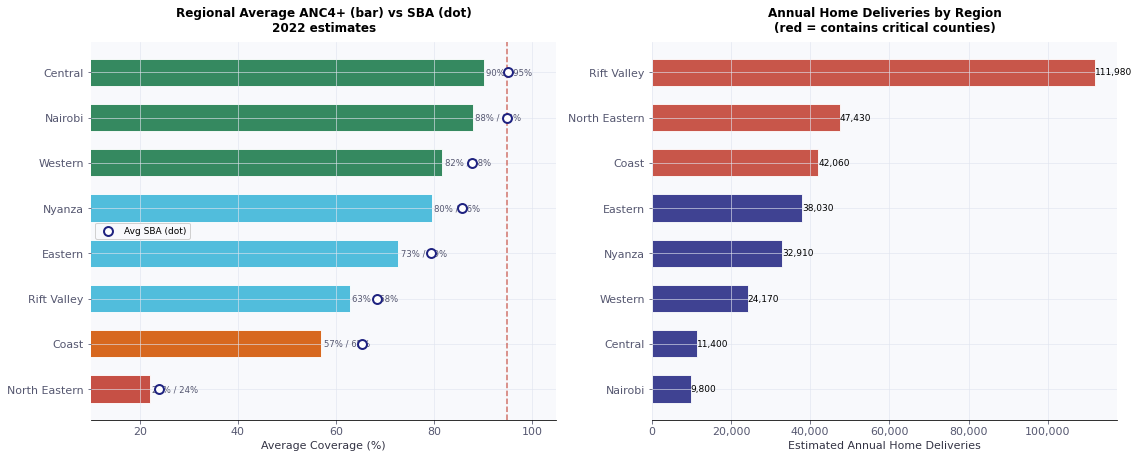

REGIONAL SUMMARY — MCH INDICATORS 2022
------------------------------------------------------------------------------
  Region           Counties   Avg ANC4   Avg SBA   Home Births   Critical
  ------------------------------------------------------------------------
  North Eastern           3      22.0%     24.0%        47,430          3
  Coast                   6      57.0%     65.3%        42,060          1
  Rift Valley            15      62.8%     68.4%       111,980          4
  Eastern                 7      72.7%     79.4%        38,030          0
  Nyanza                  5      79.6%     85.8%        32,910          0
  Western                 4      81.8%     87.8%        24,170          0
  Nairobi                 1      88.0%     95.0%         9,800          0
  Central                 5      90.2%     95.2%        11,400          0


In [7]:
# Chart 4: Regional summary and home delivery burden
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

reg_summary = df_county.groupby('Region').agg(
    Counties=('County','count'),
    Avg_ANC4=('ANC4_Coverage','mean'),
    Avg_SBA=('SBA_Coverage','mean'),
    Total_Home_Births=('Est_Home_Births','sum'),
    Critical=('ANC4_Coverage', lambda x: (x<40).sum()),
).reset_index().sort_values('Avg_ANC4', ascending=True)

reg_colors = [RED if a < 40 else (ORANGE if a < 60 else (SKY if a < 80 else GREEN))
              for a in reg_summary['Avg_ANC4']]

bars_r = axes[0].barh(reg_summary['Region'], reg_summary['Avg_ANC4'],
                      color=reg_colors, alpha=0.88, edgecolor='white', height=0.6)
axes[0].scatter(reg_summary['Avg_SBA'], reg_summary['Region'],
                color='white', s=80, zorder=6, edgecolors=NAVY, linewidth=2,
                label='Avg SBA (dot)')
axes[0].axvline(ANC_TGT, color=RED, linewidth=1.5, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Average Coverage (%)', fontsize=11)
axes[0].set_title('Regional Average ANC4+ (bar) vs SBA (dot)\n2022 estimates', fontsize=12, pad=10)
axes[0].set_xlim(10, 105)
axes[0].legend(fontsize=9)

for bar, row in zip(bars_r, reg_summary.itertuples()):
    axes[0].text(row.Avg_ANC4 + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{row.Avg_ANC4:.0f}% / {row.Avg_SBA:.0f}%',
                 va='center', fontsize=8.5, color=MID)

# Right: Home births by region
reg_home   = reg_summary.sort_values('Total_Home_Births', ascending=True)
home_colors = [RED if row.Critical > 0 else NAVY for row in reg_home.itertuples()]
bars_h = axes[1].barh(reg_home['Region'], reg_home['Total_Home_Births'],
                      color=home_colors, alpha=0.85, edgecolor='white', height=0.6)
axes[1].set_xlabel('Estimated Annual Home Deliveries', fontsize=11)
axes[1].set_title('Annual Home Deliveries by Region\n(red = contains critical counties)', fontsize=12, pad=10)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

for bar, val in zip(bars_h, reg_home['Total_Home_Births']):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('county_regional.png', dpi=150, bbox_inches='tight')
plt.show()

print('REGIONAL SUMMARY — MCH INDICATORS 2022')
print('-' * 78)
print(f'  {"Region":<15}  {"Counties":>8}  {"Avg ANC4":>9}  {"Avg SBA":>8}  {"Home Births":>12}  {"Critical":>9}')
print('  ' + '-' * 72)
for _, row in reg_summary.sort_values('Avg_ANC4').iterrows():
    print(f'  {row["Region"]:<15}  {row["Counties"]:>8}  {row["Avg_ANC4"]:>8.1f}%'
          f'  {row["Avg_SBA"]:>7.1f}%  {row["Total_Home_Births"]:>12,}  {row["Critical"]:>9}')

**The Rift Valley paradox**

The Rift Valley showed the widest intra-regional variation in Kenya. Some Rift Valley counties — Uasin Gishu at 82%, Kericho at 82%, Elgeyo Marakwet at 80% — performed well above the national average. Others — Turkana at 28%, West Pokot at 36%, Samburu at 32%, Marsabit at 35% — were in the critical category. These counties shared the same administrative region and the same regional health budget, but they were separated by geography, population density, pastoralist culture and decades of differential infrastructure investment.

The home births chart brought the equity stakes into concrete numbers. North Eastern region — with the three worst-performing counties in Kenya — generated a disproportionate share of unattended deliveries relative to its population size. Central region was the strongest performer: every single one of its counties was at or above the 80% ANC4+ threshold.

---

<a id='s7'></a>
## 7. Equity Analysis — Who Gets Left Behind

National and county averages masked a further layer of inequality. Within every county, maternal health outcomes differed systematically by wealth, residence and maternal education. I disaggregated the Kenya national figures across three equity dimensions from KDHS 2022: urban versus rural residence, wealth quintile and maternal education level.

The question I was trying to answer: if the national figure is 67% ANC4+, who is the woman at the bottom of that distribution, and what does her actual experience of the health system look like?

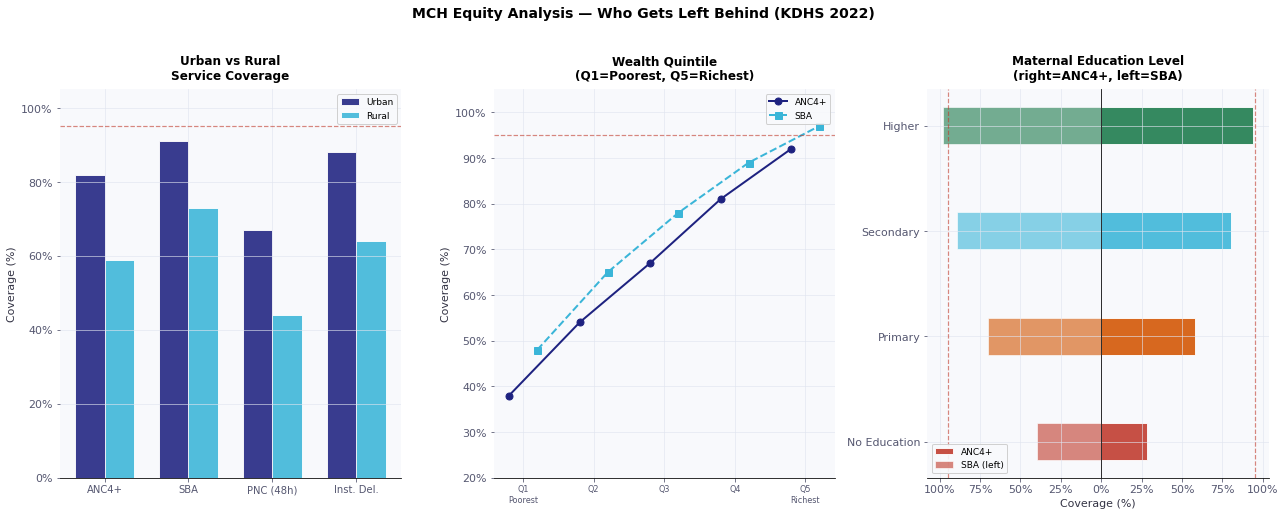

EQUITY GAPS — ANC4+ AND SBA COVERAGE (KDHS 2022)
--------------------------------------------------------------------

Urban vs Rural:
  Urban       ANC4:  82%  SBA:  91%
  Rural       ANC4:  59%  SBA:  73%

Wealth Quintile:
  Q1 — Poorest          ANC4:  38%  SBA:  48%
  Q2                    ANC4:  54%  SBA:  65%
  Q3                    ANC4:  67%  SBA:  78%
  Q4                    ANC4:  81%  SBA:  89%
  Q5 — Richest          ANC4:  92%  SBA:  97%

Maternal Education:
  No Education        ANC4:  28%  SBA:  40%
  Primary             ANC4:  58%  SBA:  70%
  Secondary           ANC4:  80%  SBA:  89%
  Higher              ANC4:  94%  SBA:  98%

KEY EQUITY GAPS:
  Urban vs Rural ANC4+ gap          : 23pp
  Richest vs Poorest ANC4+ gap      : 54pp
  Higher vs No Education ANC4+ gap  : 66pp


In [8]:
# Chart 5: Equity analysis — wealth, residence, education
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('MCH Equity Analysis — Who Gets Left Behind (KDHS 2022)',
             fontsize=14, fontweight='bold', y=1.02)

# Left: Urban vs Rural
ur = df_equity[df_equity['Stratification_Type'] == 'Urban/Rural'].copy()
x  = np.arange(4)
ind_labels = ['ANC4+', 'SBA', 'PNC (48h)', 'Inst. Del.']
ind_cols   = ['ANC4_Coverage','SBA_Coverage','PNC_Coverage','Institutional_Delivery']
w = 0.35

for i, (strat, color) in enumerate(zip(ur['Stratum'], [NAVY, SKY])):
    row  = ur[ur['Stratum'] == strat].iloc[0]
    vals = [row[c] for c in ind_cols]
    axes[0].bar(x + (i-0.5)*w, vals, w, label=strat, color=color, alpha=0.88, edgecolor='white')

axes[0].axhline(ANC_TGT, color=RED, linewidth=1.2, linestyle='--', alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ind_labels, fontsize=10)
axes[0].set_ylim(0, 105)
axes[0].set_title('Urban vs Rural\nService Coverage', fontsize=12, pad=10)
axes[0].set_ylabel('Coverage (%)', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Middle: Wealth quintile
wq = df_equity[df_equity['Stratification_Type'] == 'Wealth Quintile'].copy()
quintile_colors = [RED, ORANGE, AMBER, SKY, GREEN]

axes[1].plot(np.arange(5) - 0.2, wq['ANC4_Coverage'].values,
             color=NAVY, linewidth=2, label='ANC4+', marker='o', markersize=7)
axes[1].plot(np.arange(5) + 0.2, wq['SBA_Coverage'].values,
             color=SKY, linewidth=2, label='SBA', marker='s', markersize=7, linestyle='--')

axes[1].axhline(ANC_TGT, color=RED, linewidth=1.2, linestyle='--', alpha=0.6)
axes[1].set_xticks(range(5))
# Fix: build tick labels without literal newlines
quintile_tick_labels = [q.replace(' — ', '\n') for q in wq['Stratum']]
axes[1].set_xticklabels(quintile_tick_labels, fontsize=8)
axes[1].set_ylim(20, 105)
axes[1].set_title('Wealth Quintile\n(Q1=Poorest, Q5=Richest)', fontsize=12, pad=10)
axes[1].set_ylabel('Coverage (%)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Right: Maternal education
ed = df_equity[df_equity['Stratification_Type'] == 'Maternal Education'].copy()

axes[2].barh(ed['Stratum'], ed['ANC4_Coverage'], 0.35,
             color=['#C0392BCC','#D35400CC','#3AB5D8CC','#1A7A4ACC'],
             alpha=0.88, label='ANC4+', edgecolor='white')
axes[2].barh(ed['Stratum'], -ed['SBA_Coverage'], 0.35,
             color=['#C0392B','#D35400','#3AB5D8','#1A7A4A'],
             alpha=0.6, label='SBA (left)', edgecolor='white')

axes[2].axvline(0,        color='black', linewidth=0.8)
axes[2].axvline(ANC_TGT,  color=RED, linewidth=1.2, linestyle='--', alpha=0.6)
axes[2].axvline(-SBA_TGT, color=RED, linewidth=1.2, linestyle='--', alpha=0.6)
axes[2].set_title('Maternal Education Level\n(right=ANC4+, left=SBA)', fontsize=12, pad=10)
axes[2].set_xlabel('Coverage (%)', fontsize=11)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{abs(x):.0f}%'))
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('equity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('EQUITY GAPS — ANC4+ AND SBA COVERAGE (KDHS 2022)')
print('-' * 68)

ed2 = df_equity[df_equity['Stratification_Type']=='Maternal Education']
wq2 = df_equity[df_equity['Stratification_Type']=='Wealth Quintile']
ur2 = df_equity[df_equity['Stratification_Type']=='Urban/Rural']

print('\nUrban vs Rural:')
for _, row in ur2.iterrows():
    print(f'  {row["Stratum"]:<10}  ANC4: {row["ANC4_Coverage"]:>3}%  SBA: {row["SBA_Coverage"]:>3}%')

print('\nWealth Quintile:')
for _, row in wq2.iterrows():
    print(f'  {row["Stratum"]:<20}  ANC4: {row["ANC4_Coverage"]:>3}%  SBA: {row["SBA_Coverage"]:>3}%')

print('\nMaternal Education:')
for _, row in ed2.iterrows():
    print(f'  {row["Stratum"]:<18}  ANC4: {row["ANC4_Coverage"]:>3}%  SBA: {row["SBA_Coverage"]:>3}%')

print('\nKEY EQUITY GAPS:')
urban_anc4 = ur2[ur2.Stratum=='Urban']['ANC4_Coverage'].values[0]
rural_anc4 = ur2[ur2.Stratum=='Rural']['ANC4_Coverage'].values[0]
rich_anc4  = wq2[wq2.Stratum=='Q5 — Richest']['ANC4_Coverage'].values[0]
poor_anc4  = wq2[wq2.Stratum=='Q1 — Poorest']['ANC4_Coverage'].values[0]
high_anc4  = ed2[ed2.Stratum=='Higher']['ANC4_Coverage'].values[0]
noed_anc4  = ed2[ed2.Stratum=='No Education']['ANC4_Coverage'].values[0]
print(f'  Urban vs Rural ANC4+ gap          : {urban_anc4 - rural_anc4}pp')
print(f'  Richest vs Poorest ANC4+ gap      : {rich_anc4 - poor_anc4}pp')
print(f'  Higher vs No Education ANC4+ gap  : {high_anc4 - noed_anc4}pp')

**The equity gradients were steep — and education mattered most**

The wealth quintile gradient in ANC4+ ran from 38% in the poorest households to 92% in the richest — a 54 percentage point gap. For skilled birth attendance, the gap was 49 points. These were not minor disparities. They meant a woman in the poorest fifth of Kenya's population received a fundamentally different — and far more dangerous — pregnancy experience than a woman in the richest fifth.

The education gradient was even steeper. Women with no formal education had just 28% ANC4+ coverage. Women with higher education had 94%. That 66 percentage point gap was the largest equity gap in the entire dataset. Education shaped health-seeking behaviour in ways that went beyond income — it shaped women's ability to navigate the health system, their knowledge of what services were available and their confidence in asserting their own care needs.

The urban-rural gap (82% vs 59%) was significant but smaller than the wealth and education gaps. This told me the urban-rural divide was not simply about geographic access. It was mediated by wealth and education: urban poor households had ANC4+ coverage more similar to rural poor households than to urban middle-income households.

For programme planners, the implication was clear: facility-based interventions alone would not close these gaps. The women furthest from target were not simply geographically far from a health facility. They were in households with low income, low maternal education and high barriers to engaging with a formal health system that was not primarily designed for them.

---

<a id='s8'></a>
## 8. East Africa Regional Comparison

I placed Kenya's MCH figures in regional context to understand where it sat relative to comparable countries and to identify which neighbours offered evidence of what was achievable at similar income levels.

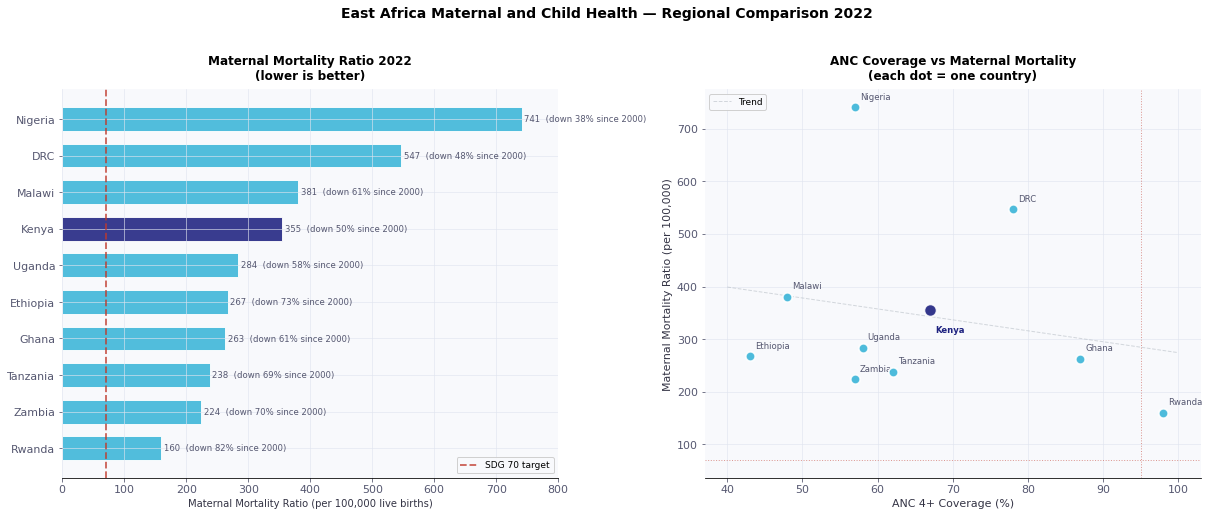

REGIONAL RANKING — MMR 2022 AND SERVICE COVERAGE
--------------------------------------------------------------------------------
  Country          MMR 2022    Reduction    ANC4%    SBA%    U5MR
  ----------------------------------------------------------------------------
  Rwanda                160          82%      98%     95%     36
  Zambia                224          70%      57%     67%     55
  Tanzania              238          69%      62%     84%     43
  Ghana                 263          61%      87%     77%     47
  Ethiopia              267          73%      43%     50%     55
  Uganda                284          58%      58%     74%     46
  Kenya                 355          50%      67%     79%     41  KENYA
  Malawi                381          61%      48%     92%     42
  DRC                   547          48%      78%     80%     76
  Nigeria               741          38%      57%     43%    117


In [9]:
# Chart 6: Regional comparison — MMR and service coverage
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('East Africa Maternal and Child Health — Regional Comparison 2022',
             fontsize=14, fontweight='bold', y=1.02)

df_r = df_regional.sort_values('MMR_2022', ascending=True).copy()
bar_colors_r = [NAVY if c == 'Kenya' else SKY for c in df_r['Country']]

# Left: MMR 2022
bars_r = axes[0].barh(df_r['Country'], df_r['MMR_2022'],
                      color=bar_colors_r, alpha=0.88, edgecolor='white', height=0.65)
axes[0].axvline(SDG_MMR, color=RED, linewidth=1.8, linestyle='--', alpha=0.8, label='SDG 70 target')
axes[0].set_xlabel('Maternal Mortality Ratio (per 100,000 live births)', fontsize=10)
axes[0].set_title('Maternal Mortality Ratio 2022\n(lower is better)', fontsize=12, pad=10)
axes[0].set_xlim(0, 800)
axes[0].legend(fontsize=9)

for bar, val, pct_red in zip(bars_r, df_r['MMR_2022'], df_r['MMR_Pct_Reduction']):
    axes[0].text(val + 4, bar.get_y() + bar.get_height()/2,
                 f'{val}  (down {pct_red:.0f}% since 2000)',
                 va='center', fontsize=8.5, color=MID)

# Right: ANC4 vs MMR scatter
for _, row in df_regional.iterrows():
    is_kenya = row['Country'] == 'Kenya'
    color    = NAVY if is_kenya else SKY
    size     = 150  if is_kenya else 90
    axes[1].scatter(row['ANC4_Latest'], row['MMR_2022'],
                    color=color, s=size, zorder=5,
                    edgecolors='white', linewidth=1.8, alpha=0.9)
    offset_y = -22 if is_kenya else 8
    axes[1].annotate(row['Country'],
                     (row['ANC4_Latest'], row['MMR_2022']),
                     textcoords='offset points', xytext=(5, offset_y),
                     fontsize=8.5,
                     color=NAVY if is_kenya else MID,
                     fontweight='bold' if is_kenya else 'normal')

from numpy.polynomial import polynomial as P
x_r   = df_regional['ANC4_Latest'].values
y_r   = df_regional['MMR_2022'].values
c_fit = np.polyfit(x_r, y_r, 1)
x_line = np.linspace(40, 100, 100)
axes[1].plot(x_line, np.polyval(c_fit, x_line),
             color=GREY, linewidth=1, linestyle='--', alpha=0.5, label='Trend')

axes[1].axvline(ANC_TGT, color=RED, linewidth=1, linestyle=':', alpha=0.5)
axes[1].axhline(SDG_MMR, color=RED, linewidth=1, linestyle=':', alpha=0.5)
axes[1].set_xlabel('ANC 4+ Coverage (%)', fontsize=11)
axes[1].set_ylabel('Maternal Mortality Ratio (per 100,000)', fontsize=11)
axes[1].set_title('ANC Coverage vs Maternal Mortality\n(each dot = one country)', fontsize=12, pad=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('regional_mch.png', dpi=150, bbox_inches='tight')
plt.show()

print('REGIONAL RANKING — MMR 2022 AND SERVICE COVERAGE')
print('-' * 80)
print(f'  {"Country":<14}  {"MMR 2022":>9}  {"Reduction":>11}  {"ANC4%":>7}  {"SBA%":>6}  {"U5MR":>6}')
print('  ' + '-' * 76)
for _, row in df_regional.sort_values('MMR_2022').iterrows():
    note = '  KENYA' if row['Country'] == 'Kenya' else ''
    print(f'  {row["Country"]:<14}  {row["MMR_2022"]:>9}  '
          f'{row["MMR_Pct_Reduction"]:>10.0f}%  {row["ANC4_Latest"]:>6}%'
          f'  {row["SBA_Latest"]:>5}%  {row["U5MR_2022"]:>5}{note}')

**Kenya's regional position on maternal mortality**

Kenya's MMR of 355 per 100,000 placed it in the middle of the East Africa pack — better than Nigeria (741), DRC (547), Malawi (381) and Ethiopia (267), but significantly worse than Rwanda (160), Tanzania (238) and Zambia (224). The 50% MMR reduction Kenya had achieved since 2000 was real and comparable to regional peers.

The ANC vs MMR scatter showed the expected inverse relationship — countries with higher ANC4+ coverage generally had lower maternal mortality. Rwanda sat at the far right (98% ANC4+, 160 MMR) — the target Kenya was trying to reach. Nigeria sat at the far left (57% ANC4+, 741 MMR), showing what the relationship looked like when service coverage failed.

Kenya's position in the scatter — 67% ANC4+, 355 MMR — was slightly above the trend line, meaning its MMR was somewhat lower than the trend would predict from its ANC coverage alone. This was partly because SBA was improving faster than ANC4+, and partly because facility delivery, once a woman reached it, was reasonably effective at preventing the most common obstetric complications.

Rwanda remained the most important reference case. 98% ANC4+, 95% SBA, 160 MMR — with a lower GDP per capita than Kenya and comparable geography. The difference was programme design and delivery quality, not simply more resources.

---

<a id='s9'></a>
## 9. Export for Power BI

The `MCH_Dashboard_Dataset.xlsx` file was structured for direct Power BI import. Each sheet mapped to a specific dashboard page.

In [10]:
import os

xl   = pd.ExcelFile('MCH_Dashboard_Dataset.xlsx')
FILE = 'MCH_Dashboard_Dataset.xlsx'

mapping = {
    'Kenya_National_MCH_Trend'  : 'Pages 2 and 3 — trend lines, SDG progress tracker',
    'Kenya_County_MCH_2022'     : 'Page 4 — county map, ANC4 and SBA ranked bars',
    'East_Africa_Regional_MCH'  : 'Page 1 — executive overview, regional benchmarking',
    'SDG3_Progress_Tracker'     : 'Page 3 — SDG progress bars, on-track status',
    'Equity_Analysis'           : 'Page 5 — equity breakdown by wealth, residence, education',
}

print('POWER BI IMPORT GUIDE')
print('=' * 70)
print('Get Data > Excel Workbook > MCH_Dashboard_Dataset.xlsx')
print()

for sheet in xl.sheet_names:
    df_tmp = pd.read_excel(FILE, sheet_name=sheet)
    page   = mapping.get(sheet, '')
    cols   = [c for c in df_tmp.columns if not c.startswith('Unnamed')][:6]
    print(f'  Sheet: {sheet}')
    print(f'    Dimensions  : {df_tmp.shape[0]} rows x {df_tmp.shape[1]} cols')
    print(f'    Dashboard   : {page}')
    print(f'    Key columns : {", ".join(cols)}')
    print()

print('Live WHO GHO OData connections:')
print('  MMR   : https://ghoapi.azureedge.net/api/MDG_0000000026')
print('  U5MR  : https://ghoapi.azureedge.net/api/MDG_0000000007')
print('  ANC4+ : https://ghoapi.azureedge.net/api/RMNCH_ANC4')
print('  No authentication required')
print()

charts = ['mch_national_trend.png','sdg_progress.png','county_anc_sba.png',
          'county_regional.png','equity_analysis.png','regional_mch.png']
print('CHART EXPORTS:')
for c in charts:
    exists = 'yes' if os.path.exists(c) else 'generates when cells run'
    print(f'  {c:<40}  {exists}')

POWER BI IMPORT GUIDE
Get Data > Excel Workbook > MCH_Dashboard_Dataset.xlsx

  Sheet: Kenya_National_MCH_Trend
    Dimensions  : 23 rows x 17 cols
    Dashboard   : Pages 2 and 3 — trend lines, SDG progress tracker
    Key columns : Year, Period, ANC1, ANC4, SBA, PNC_48hrs

  Sheet: Kenya_County_MCH_2022
    Dimensions  : 46 rows x 17 cols
    Dashboard   : Page 4 — county map, ANC4 and SBA ranked bars
    Key columns : County, County_Code, Region, Urbanization, ANC4_Coverage, SBA_Coverage

  Sheet: East_Africa_Regional_MCH
    Dimensions  : 10 rows x 20 cols
    Dashboard   : Page 1 — executive overview, regional benchmarking
    Key columns : Country, ISO3, WHO_Region, Income_Group, GAVI_Eligible, MMR_2000

  Sheet: SDG3_Progress_Tracker
    Dimensions  : 8 rows x 14 cols
    Dashboard   : Page 3 — SDG progress bars, on-track status
    Key columns : Indicator, SDG_Reference, Unit, Value_2000, Value_2015, Value_2022

  Sheet: Equity_Analysis
    Dimensions  : 11 rows x 11 cols
    D

<a id='s10'></a>
## 10. Key Findings and Dashboard Blueprint

### Eight things I found in the data

**1. MMR halved since 2000 but remains five times the SDG target.**
Kenya reduced MMR from 708 to 355 per 100,000 between 2000 and 2022. The 2030 target is 70. Reaching it required a further 285-point reduction in 8 years — faster than any 8-year improvement Kenya had ever achieved.

**2. Skilled birth attendance was Kenya's strongest MCH success.**
SBA went from 40% to 79% — the largest absolute improvement of any service coverage indicator. The Linda Mama free maternity programme (2016) and facility expansion were the primary drivers. But 21% of women still delivered without a skilled attendant.

**3. ANC4+ improved but remained 28 points short of the 95% target.**
At 67% nationally, one in three pregnant women did not complete the recommended minimum antenatal care schedule. The gap was largest in North Eastern and ASAL counties.

**4. Eight counties had ANC4+ below 40% — the critical threshold.**
Mandera (18%), Wajir (22%), Garissa (26%), Turkana (28%), Samburu (32%), Tana River (38%), Marsabit (35%) and West Pokot (36%) were all below 40%. These counties collectively accounted for approximately 55,000 unattended home deliveries per year.

**5. The wealth equity gap in ANC4+ was 54 percentage points.**
Women in the poorest wealth quintile had 38% ANC4+ coverage. Women in the richest quintile had 92%. This 54-point gap was larger than the urban-rural gap.

**6. Maternal education was the strongest predictor of service utilisation.**
Women with no education had 28% ANC4+ coverage. Women with higher education had 94%. This 66-point education gradient was the largest equity gap in the dataset.

**7. Rwanda achieved 98% ANC4+, 95% SBA and 160 MMR.**
With lower GDP per capita than Kenya and comparable geography, Rwanda demonstrated what was achievable with sustained programme commitment. The difference was programme design and delivery quality, not resource availability.

**8. None of Kenya's eight SDG 3 targets were on track for 2030.**
Every indicator I examined was off track. Progress was happening but decelerating at exactly the point it needed to accelerate.

---

### Recommended Power BI Dashboard — 5 Pages

**Page 1 — Executive Overview:** Six KPI tiles (MMR, U5MR, NMR, ANC4%, SBA%, counties below 40% ANC4). All flagged against SDG targets. Regional comparison bar for MMR. Progress summary strip.

**Page 2 — Kenya National Trends:** Multi-line service coverage chart with SDG 95% target line and COVID band. Separate mortality trend chart with MMR on secondary axis. KDHS survey year markers. Year range slicer.

**Page 3 — SDG 3 Progress Tracker:** Horizontal progress bar for each of the 8 indicators — % of journey from baseline to 2030 target completed. Current value vs target displayed. On-track / Off Track / Possible status flags.

**Page 4 — County Map and Subnational Analysis:** Kenya choropleth coloured by ANC4 category. Ranked bar chart — all 46 counties. ANC4 vs SBA scatter. Estimated home births by county. Region filter.

**Page 5 — Equity Analysis:** Urban vs Rural grouped bar. Wealth quintile line chart (Q1 to Q5 gradient). Maternal education bar. MMR Index by quintile. Stratification filter.

---

*Patience Anono — PA Data Analytics · padataanalytics.com*
*Data: KDHS 2022 · WHO GHO · World Bank HNP · Kenya KHIS 2023*